# Non-Uniform Azimuthal Poisson Solver:
# Structured Distorted Angular Grid vs. Uniform FFT with Interpolation

$$
u(r,\theta)
=
(R^2-r^2)
\left(\frac{r}{R}\right)^m
\cos\left(m(\theta-\theta_0)\right)
$$

This manufactured Poisson problem is smooth on the full disk, including at
the origin, and satisfies homogeneous Dirichlet boundary conditions:

$$
u(R,\theta)=0.
$$

The angular grid is a structured multi-pole deformation that can represent
periodic angular encoder error, scanner wobble, lens distortion, or a smoothly
distorted polar mesh.

All methods begin with the same distorted angular measurements. NUFFT (PCGLS)
and NUDFT consume those measurements directly. The Uniform FFT baseline
first applies periodic linear interpolation to place the same measurements on a
uniform angular grid before solving.

In [5]:
import os
import sys
import platform
import psutil
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = False  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab & Auto-Sync
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('/content/NUFFTRR_Poisson'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git /content/NUFFTRR_Poisson')
    
    # Fetch and hard reset to latest GitHub commit
    os.system('cd /content/NUFFTRR_Poisson && git fetch origin main && git reset --hard origin/main')
    
    if os.getcwd() != '/content/NUFFTRR_Poisson':
        os.chdir('/content/NUFFTRR_Poisson')
        
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters
num_processors = None    # Number of CPU threads (None = all available cores)
maxiter_nufft = 50       # Maximum Block-CG iterations
tol_nufft = 1e-10         # Block-CG convergence tolerance
reg_param = 1e-20        # Tikhonov regularization
eps_finufft = 1e-10       # FINUFFT kernel precision
precond_shift = 1e-5     # Preconditioner shift (T. Chan circulant)
kde_oversample = 4       # KDE oversampling factor
kde_bandwidth = 1.0      # KDE bandwidth factor

from structured_nonuniform_helpers import *

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)

# ---------------------------------------------------------
# System & Hardware Diagnostics Banner
# ---------------------------------------------------------
ram_gb = psutil.virtual_memory().total / (1024 ** 3)
ram_avail_gb = psutil.virtual_memory().available / (1024 ** 3)
cpu_cores_logical = os.cpu_count()
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_model = platform.processor() or "Generic CPU"
if IN_COLAB and os.path.exists('/proc/cpuinfo'):
    with open('/proc/cpuinfo') as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":", 1)[1].strip()
                break

backend_name = 'GPU (NVIDIA CuPy / cuFINUFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'

print('=' * 75)
print(f'  BENCHMARK ENVIRONMENT SUMMARY')
print('=' * 75)
print(f'  Active Backend  : {backend_name}')
print(f'  Environment     : {"Google Colab" if IN_COLAB else "Local Workstation"} ({platform.system()} {platform.release()})')
print(f'  Host CPU        : {cpu_model}')
print(f'  CPU Cores       : {cpu_cores_phys} Physical / {cpu_cores_logical} Logical Threads')
print(f'  System RAM      : {ram_gb:.1f} GB Total ({ram_avail_gb:.1f} GB Available)')

if USE_GPU:
    try:
        import cupy as cp
        dev = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(dev.id)
        gpu_name = props['name'].decode('utf-8') if isinstance(props['name'], bytes) else str(props['name'])
        compute_cap = f"{props['major']}.{props['minor']}"
        free_mem_gb, total_mem_gb = dev.mem_info[0] / (1024**3), dev.mem_info[1] / (1024**3)
        
        print('-' * 75)
        print(f'  GPU Device      : {gpu_name} (Compute Capability: {compute_cap})')
        print(f'  GPU VRAM        : {total_mem_gb:.1f} GB Total ({free_mem_gb:.1f} GB Free)')
        print(f'  CUDA Driver/RT  : {cp.cuda.runtime.runtimeGetVersion()}')
    except Exception as e:
        print(f'  GPU Status      : Warning - GPU query failed: {e}')

print(f'  Time Trials     : {TIME_TRIALS} (Runs = {NUM_RUNS})')
print('=' * 75)


  BENCHMARK ENVIRONMENT SUMMARY
  Active Backend  : CPU (Multithreaded FINUFFT)
  Environment     : Google Colab (Linux 6.6.122+)
  Host CPU        : Intel(R) Xeon(R) CPU @ 2.20GHz
  CPU Cores       : 6 Physical / 12 Logical Threads
  System RAM      : 53.0 GB Total (51.1 GB Available)
  Time Trials     : True (Runs = 5)


## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [6]:
# ---------------------------------------------------------
# Disk and smooth single-multipole manufactured problem
# ---------------------------------------------------------
R = 1.0
MODE = 16
THETA_0 = np.pi


# ---------------------------------------------------------
# Structured multi-pole angular distortion
#
# theta(xi) = xi + 0.08 sin(2 xi) + 0.04 sin(4 xi)
#
# Monotonicity / distortion measure:
# 0.08 * 2 + 0.04 * 4 = 0.32 < 1.
#
# This is milder than the previous 0.60 distortion measure,
# improving NUFFT CGLS conditioning while retaining realistic
# periodic structured angular distortion.
# ---------------------------------------------------------
GRID_POLES = (2, 4)
GRID_AMPLITUDES = (0.08, 0.04)


# ---------------------------------------------------------
# Solver settings
# ---------------------------------------------------------
QUAD_RULE = 2                # 1: Trapezoidal, 2: Simpson
BC_CHOICE = 1                # 1: Dirichlet, 2: Neumann


# ---------------------------------------------------------
# Resolution study
#
# MODE=16 needs enough angular samples. N=64 is the first
# meaningful resolution in this study.
# ---------------------------------------------------------
N_VALUES = [64, 128, 256]
M_VALUES = [64, 128, 256]


# ---------------------------------------------------------
# Fixed settings for plots
# ---------------------------------------------------------
N_LOW_ADAPT = 64
N_HIGH_UNIFORM = 1024
M_FIXED_PLOTS = 128

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

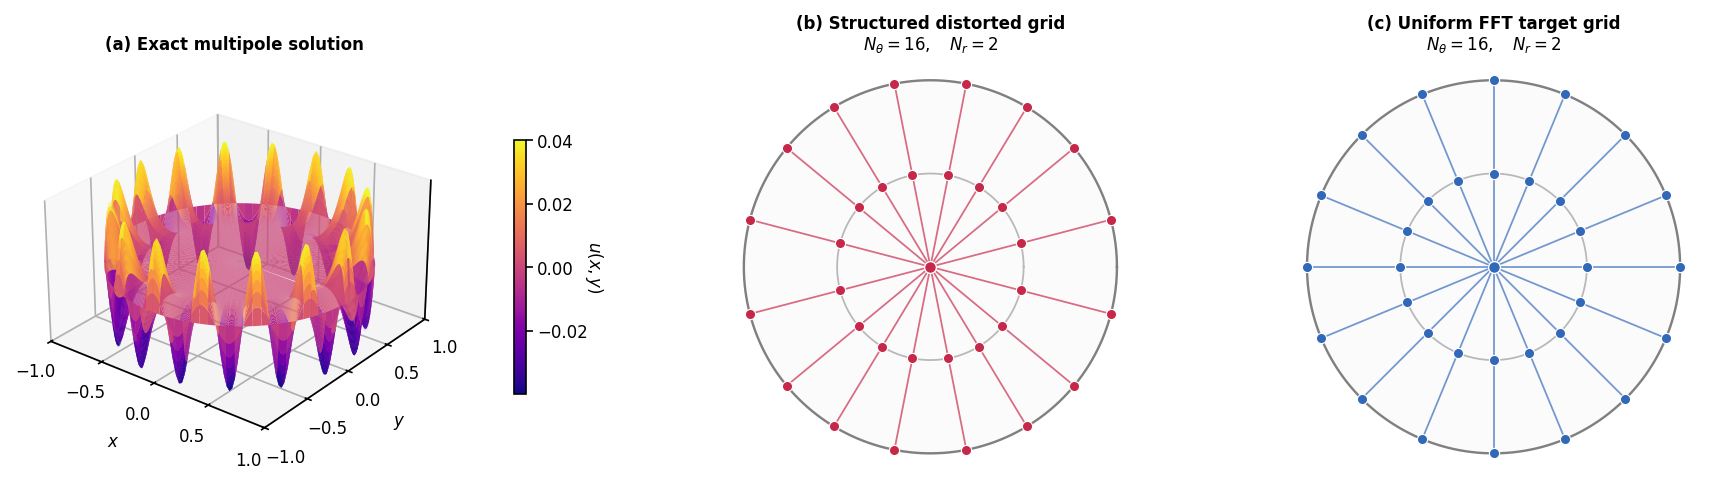

In [7]:
# Construct smooth single-multipole manufactured problem.
problem = get_single_multipole_problem(
    R=R,
    mode=MODE,
    theta_0=THETA_0,
)

# Visualize exact solution, structured distorted measurement grid,
# and Uniform FFT target grid.
plot_solution_and_grids(
    problem=problem,
    N_adapt=16,
    N_unif=16,
    M=2,
    poles=GRID_POLES,
    amplitudes=GRID_AMPLITUDES,
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **NUFFT (PCGLS)**, **NUDFT**, and **Uniform FFT + cubic spline**.

In [8]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    poles=GRID_POLES,
    amplitudes=GRID_AMPLITUDES,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE,
    maxiter_nufft=maxiter_nufft,
    tol_nufft=tol_nufft,
    reg_param=reg_param,
    eps_finufft=eps_finufft,
    precond_shift=precond_shift,
    kde_oversample=kde_oversample,
    kde_bandwidth=kde_bandwidth,
    num_processors=num_processors,
    use_gpu=USE_GPU,
    time_trials=TIME_TRIALS,
    num_runs=NUM_RUNS,
)


Computing N x M multipole-grid study [CPU]:   0%|          | 0/27 [00:00<?, ?it/s]

## 4. $L_2$ Error 
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [9]:
# Relative L2 Error Tables for each algorithm
combined_error = render_combined_error_table(df_results, value_col="L2_rel")

## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

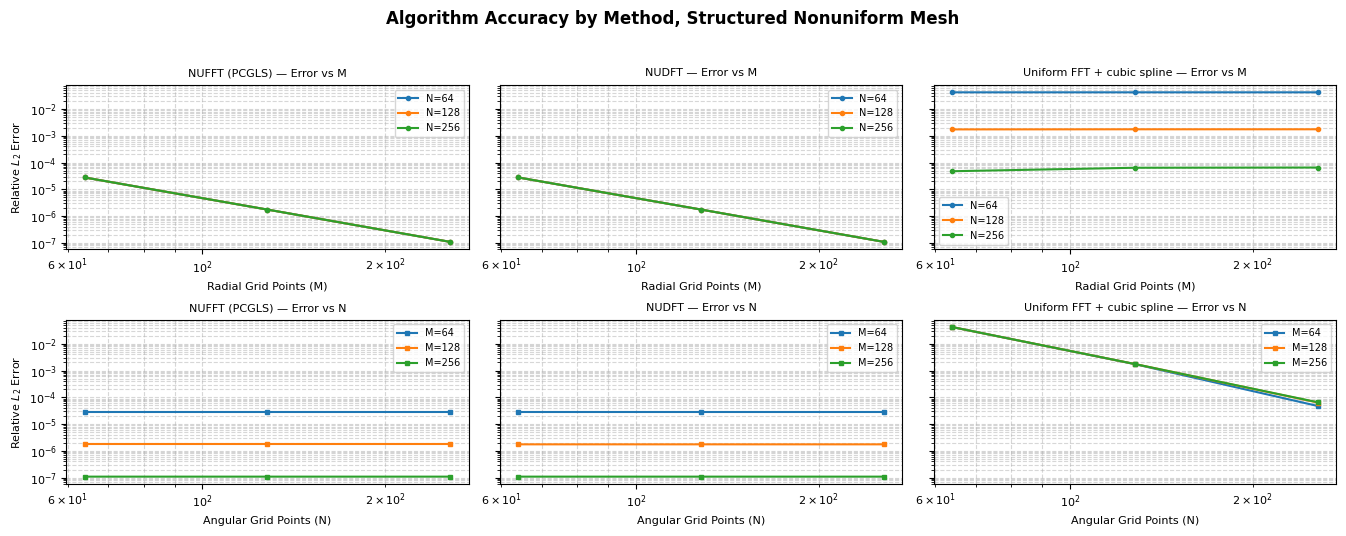

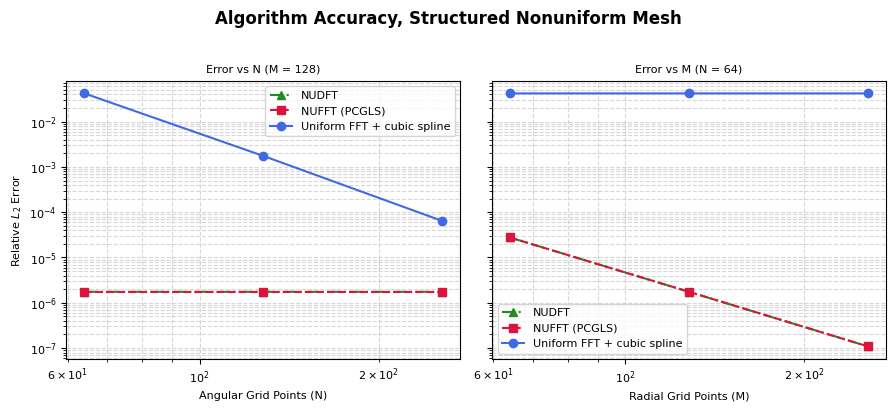

In [10]:
plot_accuracy_faceted_by_method(df_results, N_values=N_VALUES, M_values=M_VALUES)

plot_accuracy_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=N_LOW_ADAPT
)


## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing NUFFT (PCGLS) ($N=32$) and NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).


1 x 3 Disk Error Comparison with NUDFT Table Result
                                                  Case    N   M Relative L2 Relative Linf Runtime (s)
                 NUFFT (PCGLS) — direct distorted data   64 128   1.748e-06     1.662e-06      0.1013
                         NUDFT — direct distorted data   64 128   1.748e-06     1.662e-06      0.1529
  Uniform FFT + cubic spline — same measurement budget   64 128   4.191e-02     9.367e-02      0.0046
Uniform FFT + cubic spline — higher measurement budget 1024 128   1.582e-06     1.620e-06      0.0368


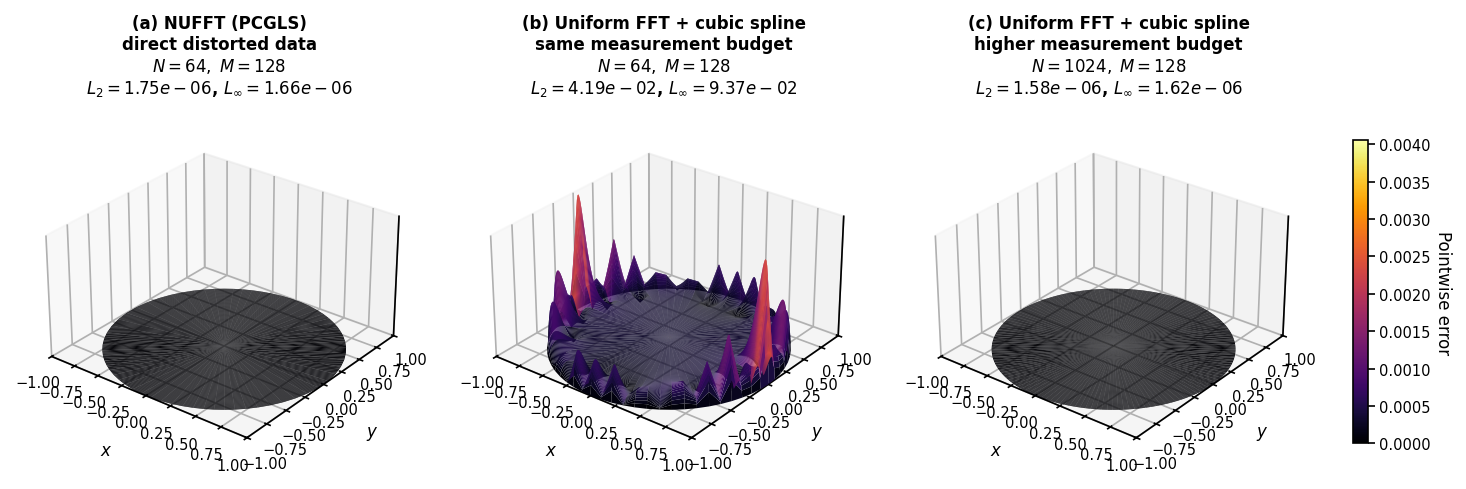

,Case,N,M,Relative L2,Relative Linf,Runtime (s)
0,NUFFT (PCGLS) — direct distorted data,64,128,0.000002,0.000002,0.101346
1,NUDFT — direct distorted data,64,128,0.000002,0.000002,0.152934
2,Uniform FFT + cubic spline — same measurement ...,64,128,0.041905,0.093672,0.004604
3,Uniform FFT + cubic spline — higher measuremen...,1024,128,0.000002,0.000002,0.036833


In [11]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    poles=GRID_POLES,
    amplitudes=GRID_AMPLITUDES,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE,
    maxiter_nufft=maxiter_nufft,
    tol_nufft=tol_nufft,
    reg_param=reg_param,
    eps_finufft=eps_finufft,
    precond_shift=precond_shift,
    kde_oversample=kde_oversample,
    kde_bandwidth=kde_bandwidth,
    num_processors=num_processors,
    use_gpu=USE_GPU,
    time_trials=TIME_TRIALS,
    num_runs=NUM_RUNS,
)


Runtime Tables ($N$ vs. $M$)


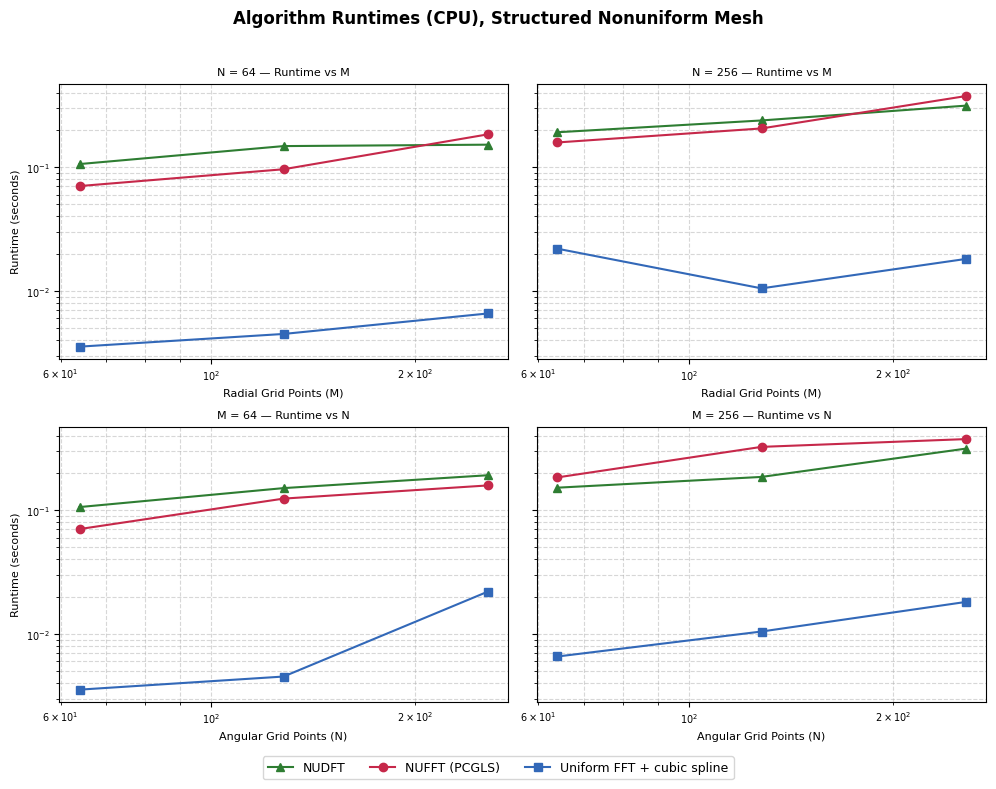

In [12]:
# Runtime (seconds) Tables for each algorithm
combined_runtime = render_combined_runtime_table(df_results)

plot_extreme_runtime_2x2(df_results, use_gpu=USE_GPU)
